In [20]:
import torch
import yaml
from pprint import pprint
from helper import load_default_dataloaders, load_ObjDet_model, load_best_model, get_bbox_preds, visualize_bbox_preds
from helper.utils import get_box_coords
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [21]:
torch.manual_seed(42)

In [22]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


## Loading Object Detection Model and Dataset

In [23]:
dataset_path = "../kaggle/Traffic_Sign/car"
batch_size = 16
num_workers = 0 # multiple workers will not work in a ipynb on macOS

In [24]:
# load class names from yaml file

with open(f"{dataset_path}/data.yaml", "r") as f:
    class_names = yaml.safe_load(f)["names"]

In [25]:
# building the model with the new object detection head, getting the test dataloader from the weights preprocessing and the new input image size after the preprocessing transformations

model, test_transform, image_size = load_ObjDet_model(num_classes=len(class_names), frozen=True, device=device)

In [26]:
_, _, test_dataloader = load_default_dataloaders(
    batch_size=batch_size,
    num_workers=num_workers, 
    image_size=image_size, 
    test_transform=test_transform, 
    dataset_path=dataset_path
)

In [27]:
load_best_model(model)
model.eval()

Best model file: TrafficSign_ObjDet_finetune_1.1770.pth


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


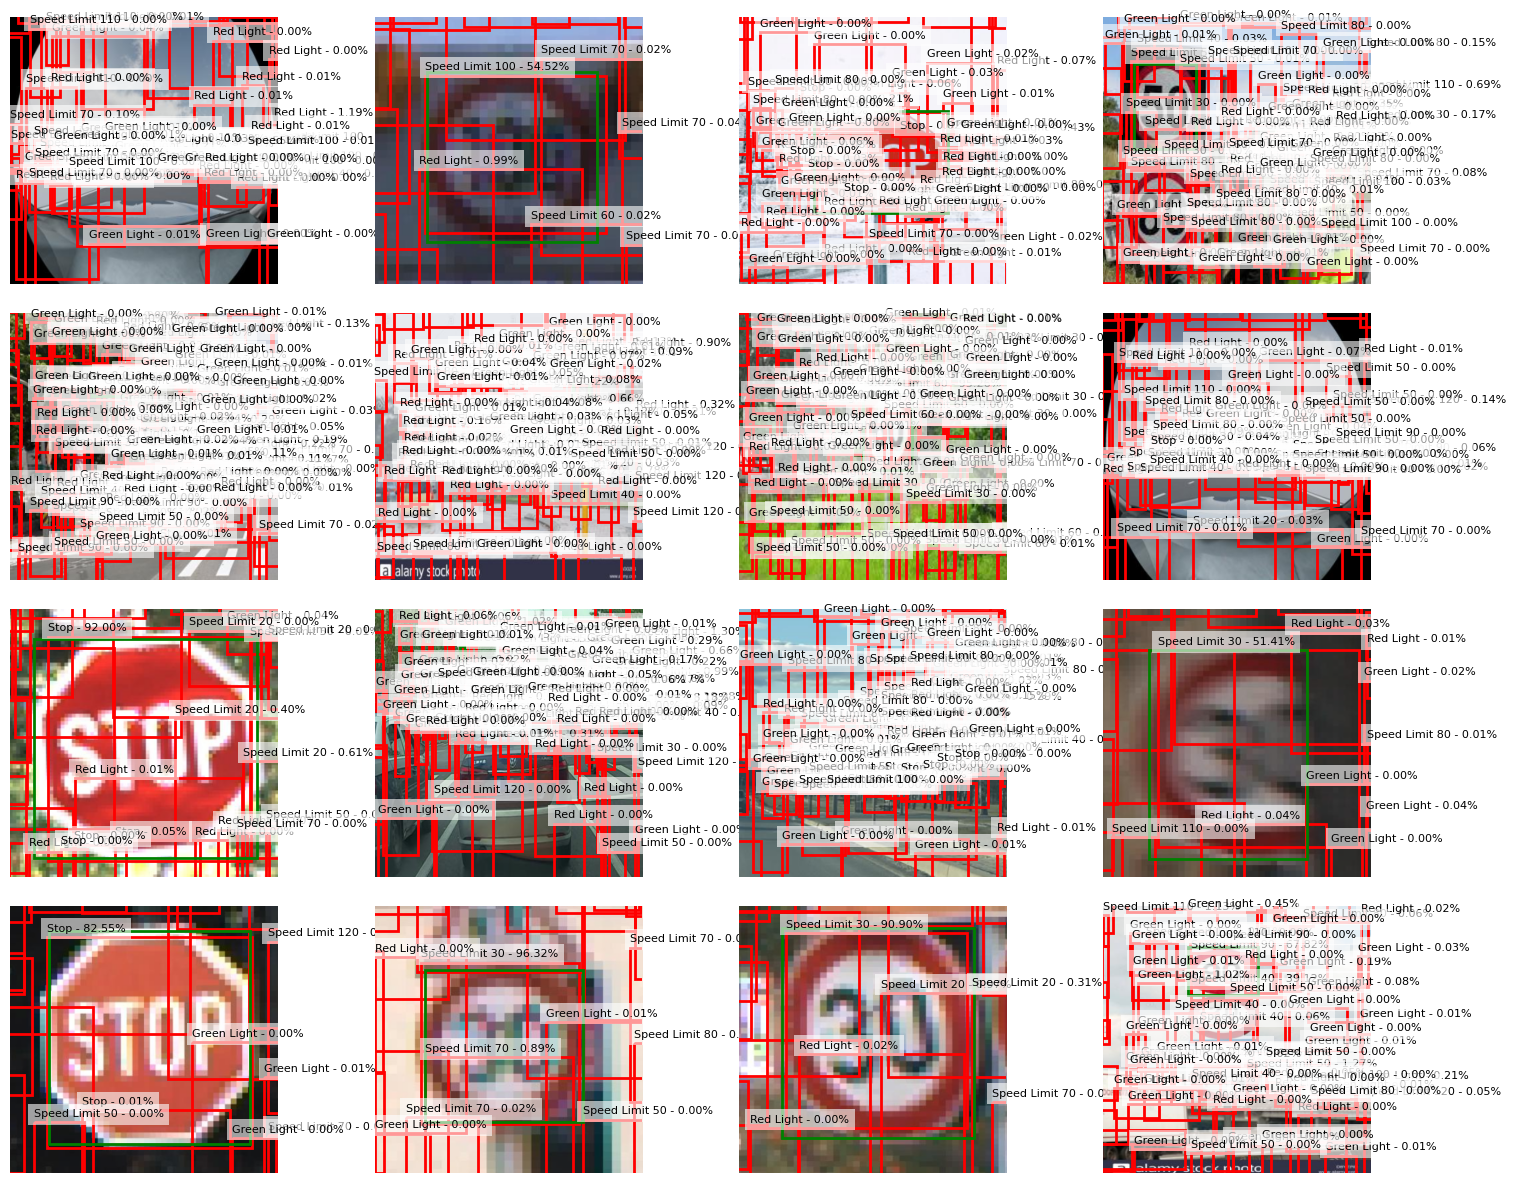

In [ ]:
# compare the predicted bounding boxes with the GT bounding boxes
val_batch = next(iter(test_dataloader))
X, y = torch.stack(val_batch[0]).to(device), val_batch[1] # torch.stack() because the batch is a tuple of 64 images and 64 labels
with torch.no_grad():
    pred = model(X)
    pred_classes, pred_bboxes, pred_confidences = get_bbox_preds(batch_size=batch_size, pred=pred, threshold=0.25, image_size=image_size, nms_treshold=0.5)
    visualize_bbox_preds(X.to('cpu'), pred_classes, pred_bboxes, pred_confidences, y=y, image_size=X.shape[-1], test_transforms=test_transform, class_names=class_names)

In [ ]:
metric = MeanAveragePrecision(iou_type="bbox")

with torch.no_grad():
    for batch in test_dataloader:
        X, y = torch.stack(batch[0]).to(device), batch[1]
        pred = model(X)
        pred_classes, pred_bboxes, pred_confidences = get_bbox_preds(batch_size=batch_size, pred=pred, threshold=0.0, image_size=image_size, nms_treshold=0.5)
        preds_dict = [{
                "boxes": box.detach().cpu(),
                "scores": conf.detach().cpu(),
                "labels": cls.detach().cpu()
            }
            for box, conf, cls in zip(pred_bboxes, pred_confidences, pred_classes)
        ]  

        target_dict = []
        for img in y:
            classes = []
            locs = []
            for obj in img:
                classes.append(obj[0])
                x1, y1, w, h = get_box_coords(obj, image_size)
                locs.append([x1, y1, x1 + w, y1 + h])
            target_dict.append({
                "boxes": torch.tensor(locs), 
                "labels": torch.tensor(classes).to(torch.int64)
                }
            )
        
        metric.update(preds=preds_dict, target=target_dict)


In [ ]:
pprint(metric.compute())

# some images only define one bounding box as the ground truth, despite there being multiple objects in the image
# the network is able to predict those multiple objects, performing better than the ground truth, but the mAP metric will punish that anyway
# => so those metrics are not 100% reliable (recall is more reliable than precision in this case), but reflect the performance in a general way

{'classes': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
       dtype=torch.int32),
 'map': tensor(0.4487),
 'map_50': tensor(0.6701),
 'map_75': tensor(0.5146),
 'map_large': tensor(0.6822),
 'map_medium': tensor(0.3871),
 'map_per_class': tensor(-1.),
 'map_small': tensor(0.0882),
 'mar_1': tensor(0.5310),
 'mar_10': tensor(0.5506),
 'mar_100': tensor(0.5506),
 'mar_100_per_class': tensor(-1.),
 'mar_large': tensor(0.7229),
 'mar_medium': tensor(0.4412),
 'mar_small': tensor(0.1543)}
